# LLM — Tópicos Dinámicos

El modelo descubre aspectos libremente, sin taxonomía predefinida. Dataset: `reviews_clean.csv`.

In [6]:
import sys
sys.path.append('..')

import pickle
import time
import json
import re
import os
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
from huggingface_hub import InferenceClient

In [ ]:
HF_TOKEN = os.environ.get('HF_TOKEN', 'XXXX')
MODEL_ID  = 'Qwen/Qwen2.5-7B-Instruct'

client = InferenceClient(model=MODEL_ID, token=HF_TOKEN)

In [8]:
SYSTEM_PROMPT = """Eres un analizador de reseñas de hoteles en español. Dado un texto, extrae todos los aspectos mencionados y su sentimiento.

Para cada aspecto identificado, devuelve:
- aspecto: nombre del aspecto (libre, el que mejor describa lo que se comenta)
- polaridad: positive, negative o neutral
- fragmento: texto exacto de la review que justifica el aspecto (máximo 10 palabras)

Responde SOLO con JSON válido:
[{"aspecto": "...", "polaridad": "...", "fragmento": "..."}]

Si no se menciona ningún aspecto concreto del hotel, responde: []
"""

FEW_SHOT = """Review: El desayuno estaba delicioso pero la habitación era ruidosa y el wifi no funcionaba.
Respuesta: [{"aspecto": "desayuno", "polaridad": "positive", "fragmento": "desayuno estaba delicioso"}, {"aspecto": "ruido en habitación", "polaridad": "negative", "fragmento": "habitación era ruidosa"}, {"aspecto": "wifi", "polaridad": "negative", "fragmento": "wifi no funcionaba"}]

Review: Ubicación perfecta, a dos pasos del metro. El personal muy atento en todo momento.
Respuesta: [{"aspecto": "ubicación", "polaridad": "positive", "fragmento": "Ubicación perfecta, a dos pasos del metro"}, {"aspecto": "atención del personal", "polaridad": "positive", "fragmento": "personal muy atento"}]

"""

In [9]:
def parse_llm_response(text):
    text = text.strip()
    try:
        return json.loads(text)
    except json.JSONDecodeError:
        pass
    match = re.search(r'\[.*?\]', text, re.DOTALL)
    if match:
        try:
            return json.loads(match.group())
        except Exception:
            pass
    return []

def predict_aspects_dinamico(review_text):
    user_content = FEW_SHOT + f'Review: {review_text}\nRespuesta:'
    messages = [
        {'role': 'system', 'content': SYSTEM_PROMPT},
        {'role': 'user', 'content': user_content},
    ]
    response = client.chat_completion(model=MODEL_ID,messages=messages, max_tokens=512, temperature=0.1)
    raw = response.choices[0].message.content
    return parse_llm_response(raw)

## Inferencia sobre dataset propio

In [10]:
df = pd.read_csv('../data/reviews_clean.csv')

N_SAMPLE = None
if N_SAMPLE:
    df = df.sample(N_SAMPLE, random_state=42).reset_index(drop=True)

print(f'Procesando {len(df)} reviews...')

Procesando 8076 reviews...


In [11]:
import time

all_results = []
errors = 0
t0 = time.time()

# 1. Separar el subset de pruebas para que los cálculos sean correctos
df_subset = df.head(13) 

for i, row in df_subset.iterrows():
    try:
        texto_resena = row['review']
        time.sleep(0.5)
        aspects = predict_aspects_dinamico(texto_resena)
        print(f"Fila {i} | Predicción: {aspects}")
        all_results.append(aspects)
        
    except Exception as e:
        # 3. NUNCA silenciar las excepciones durante las pruebas
        print(f"Fila {i} | ERROR DETECTADO: {type(e).__name__} - {e}")
        all_results.append([])
        errors += 1

elapsed = time.time() - t0

# 4. Calcular sobre len(df_subset), no sobre len(df)
if len(df_subset) > 0:
    print(f'\nTotal: {elapsed:.1f}s — {1000*elapsed/len(df_subset):.1f}ms/review — Errores: {errors}')

Fila 0 | Predicción: [{'aspecto': 'ubicación', 'polaridad': 'positive', 'fragmento': 'Ubicación perfecta, a dos pasos del metro'}, {'aspecto': 'descanso', 'polaridad': 'negative', 'fragmento': 'fue IMPOSIBLE por los ruidos constantes'}, {'aspecto': 'limpieza', 'polaridad': 'negative', 'fragmento': 'limpiadoras moviendo muebles'}]
Fila 1 | Predicción: [{'aspecto': 'ubicación', 'polaridad': 'positive', 'fragmento': 'Ubicación perfecta, a dos pasos del metro'}, {'aspecto': 'espacio de las habitaciones', 'polaridad': 'positive', 'fragmento': 'las habtiaciones son espaciosas'}, {'aspecto': 'atención del personal', 'polaridad': 'positive', 'fragmento': 'personal es muy amable'}, {'aspecto': 'zona de la piscina', 'polaridad': 'positive', 'fragmento': 'la zona de la piscina es curiosa'}, {'aspecto': 'conexión wifi', 'polaridad': 'negative', 'fragmento': 'wifi no llegaba bien a la habitación'}, {'aspecto': 'sábanas en verano', 'polaridad': 'negative', 'fragmento': 'poner un edredón nórdico en p

## Análisis de aspectos descubiertos

In [12]:
flat_aspects = [item for review_aspects in all_results for item in review_aspects]
reviews_with_aspects = sum(1 for r in all_results if r)

aspect_counter = Counter(item.get('aspecto', '').lower().strip() for item in flat_aspects)
polarity_counter = Counter(item.get('polaridad', '') for item in flat_aspects)
aspects_per_review = [len(r) for r in all_results]

import numpy as np
print(f'Reviews con al menos 1 aspecto: {reviews_with_aspects} ({100*reviews_with_aspects/len(df):.1f}%)')
print(f'Total aspectos extraídos:        {len(flat_aspects)}')
print(f'Aspectos únicos:                 {len(aspect_counter)}')
print(f'Aspectos/review promedio:        {np.mean(aspects_per_review):.2f} (reviews con aspectos: {np.mean([x for x in aspects_per_review if x]):.2f})')
print(f'Distribución polaridades:        {dict(polarity_counter)}')

Reviews con al menos 1 aspecto: 9 (0.1%)
Total aspectos extraídos:        44
Aspectos únicos:                 39
Aspectos/review promedio:        3.38 (reviews con aspectos: 4.89)
Distribución polaridades:        {'positive': 8, 'negative': 36}


In [13]:
top_aspects = aspect_counter.most_common(20)

pol_by_aspect = defaultdict(Counter)
for item in flat_aspects:
    asp = item.get('aspecto', '').lower().strip()
    pol = item.get('polaridad', '')
    pol_by_aspect[asp][pol] += 1

print(f'\n{"Aspecto":<35} {"Total":>6} {"POS":>5} {"NEG":>5} {"NEU":>5}')
print('-' * 60)
for asp, total in top_aspects:
    pols = pol_by_aspect[asp]
    print(f'{asp:<35} {total:>6} {pols.get("positive",0):>5} {pols.get("negative",0):>5} {pols.get("neutral",0):>5}')


Aspecto                              Total   POS   NEG   NEU
------------------------------------------------------------
ubicación                                3     3     0     0
atención del personal                    3     2     1     0
limpieza de habitación                   2     0     2     0
descanso                                 1     0     1     0
limpieza                                 1     0     1     0
espacio de las habitaciones              1     1     0     0
zona de la piscina                       1     1     0     0
conexión wifi                            1     0     1     0
sábanas en verano                        1     0     1     0
hotel moderno                            1     1     0     0
ruido                                    1     0     1     0
piscina                                  1     0     1     0
funcionamiento de la habitación          1     0     1     0
atención de recepción                    1     0     1     0
temperatura            

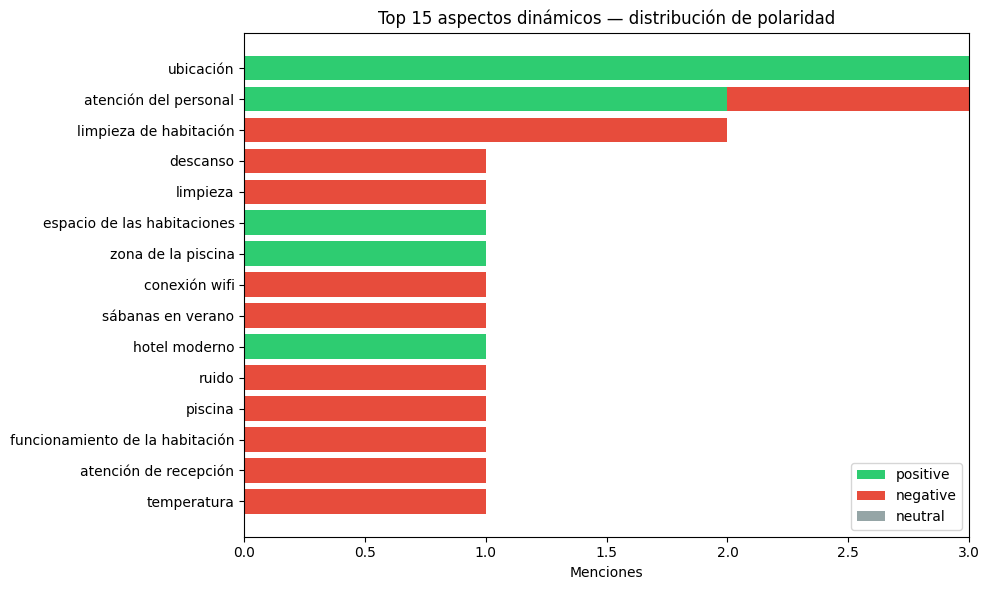

In [14]:
top_names = [a for a, _ in top_aspects[:15]]
pos_vals = [pol_by_aspect[a].get('positive', 0) for a in top_names]
neg_vals = [pol_by_aspect[a].get('negative', 0) for a in top_names]
neu_vals = [pol_by_aspect[a].get('neutral', 0) for a in top_names]

fig, ax = plt.subplots(figsize=(10, 6))
y = range(len(top_names))
ax.barh(y, pos_vals, label='positive', color='#2ecc71')
ax.barh(y, neg_vals, left=pos_vals, label='negative', color='#e74c3c')
ax.barh(y, neu_vals, left=[p+n for p,n in zip(pos_vals,neg_vals)], label='neutral', color='#95a5a6')
ax.set_yticks(list(y))
ax.set_yticklabels(top_names)
ax.invert_yaxis()
ax.legend(loc='lower right')
ax.set_title('Top 15 aspectos dinámicos — distribución de polaridad')
ax.set_xlabel('Menciones')

plt.tight_layout()
plt.savefig('../results/figures/llm_dinamico_aspectos.png', bbox_inches='tight')
plt.show()

### Prueba con modelo local (Ollama)

In [15]:
# ── Celda: Configuración cliente Ollama ──────────────────────────────────────
import requests

OLLAMA_URL   = "http://localhost:11434/api/chat"
OLLAMA_MODEL = "qwen3.5:2b"

def predict_aspects_ollama_dinamico(review_text, model=OLLAMA_MODEL):
    user_content = FEW_SHOT + f'Review: {review_text}\nRespuesta:'
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user",   "content": user_content},
    ]
    payload = {
        "model": model,
        "messages": messages,
        "stream": False,
        "think": False,          # desactiva thinking mode (Qwen3)
        "options": {"temperature": 0.1, "num_predict": 512}
    }
    resp = requests.post(OLLAMA_URL, json=payload, timeout=120)
    resp.raise_for_status()
    raw = resp.json()["message"]["content"]
    return parse_llm_response(raw)


In [21]:
# ── Celda: Inferencia con Ollama ──────────────────────────────────────────────
all_results_ollama = []
errors_ollama = 0
t0_ollama = time.time()

df_subset_ollama = df.head(100)

for i, row in df_subset_ollama.iterrows():
    try:
        aspects = predict_aspects_ollama_dinamico(row['review'])
        print(f"Fila {i} | {aspects}")
        all_results_ollama.append(aspects)
    except Exception as e:
        print(f"Fila {i} | ERROR: {type(e).__name__} - {e}")
        all_results_ollama.append([])
        errors_ollama += 1

elapsed_ollama = time.time() - t0_ollama
print(f'\nTotal: {elapsed_ollama:.1f}s — {1000*elapsed_ollama/len(df_subset_ollama):.1f}ms/review — Errores: {errors_ollama}')


Fila 0 | [{'aspecto': 'ubicación', 'polaridad': 'negative', 'fragmento': 'ala bastante apartada'}, {'aspecto': 'ruidos', 'polaridad': 'negative', 'fragmento': 'ruidos constantes'}, {'aspecto': 'limpieza', 'polaridad': 'negative', 'fragmento': 'limpiadoras moviendo muebles'}]
Fila 1 | [{'aspecto': 'ubicación', 'polaridad': 'neutral', 'fragmento': 'El hotel en general está bien'}, {'aspecto': 'habitaciones', 'polaridad': 'positive', 'fragmento': 'las habtiaciones son espaciosas'}, {'aspecto': 'personal', 'polaridad': 'positive', 'fragmento': 'el personal es muy amable'}, {'aspecto': 'servicio wifi', 'polaridad': 'negative', 'fragmento': 'el wifi no llegaba bien a la habitación'}, {'aspecto': 'servicio habitaciones', 'polaridad': 'negative', 'fragmento': 'no se les ocurre otra cosa que poner un edredón nórdico'}]
Fila 2 | [{'aspecto': 'modernidad', 'polaridad': 'positive', 'fragmento': 'El hotel es moderno'}, {'aspecto': 'amplitud', 'polaridad': 'positive', 'fragmento': 'El hotel es ampli

In [ ]:
# ── Celda: Análisis Ollama ────────────────────────────────────────────────────
flat_ollama = [item for r in all_results_ollama for item in r]
aspect_counter_ollama  = Counter(item.get('aspecto', '').lower().strip() for item in flat_ollama)
polarity_counter_ollama = Counter(item.get('polaridad', '') for item in flat_ollama)
aspects_per_review_ollama = [len(r) for r in all_results_ollama]
reviews_with_aspects_ollama = sum(1 for r in all_results_ollama if r)

print(f"=== Ollama ({OLLAMA_MODEL}) ===")
print(f"Reviews con aspectos:     {reviews_with_aspects_ollama}/{len(df_subset_ollama)}")
print(f"Total aspectos:           {len(flat_ollama)}")
print(f"Aspectos únicos:          {len(aspect_counter_ollama)}")
print(f"Aspectos/review promedio: {np.mean(aspects_per_review_ollama):.2f}")
print(f"Distribución polaridades: {dict(polarity_counter_ollama)}")
print(f"ms/review:                {1000*elapsed_ollama/len(df_subset_ollama):.1f}")

print(f'\n{"Aspecto":<35} {"Total":>6} {"POS":>5} {"NEG":>5} {"NEU":>5}')
print('-' * 60)
pol_by_aspect_ollama = defaultdict(Counter)
for item in flat_ollama:
    asp = item.get('aspecto', '').lower().strip()
    pol_by_aspect_ollama[asp][item.get('polaridad', '')] += 1

for asp, total in aspect_counter_ollama.most_common(20):
    pols = pol_by_aspect_ollama[asp]
    print(f'{asp:<35} {total:>6} {pols.get("positive",0):>5} {pols.get("negative",0):>5} {pols.get("neutral",0):>5}')


=== Ollama (qwen3.5:2b) ===
Reviews con aspectos:     12/13
Total aspectos:           66
Aspectos únicos:          43
Aspectos/review promedio: 5.08
Distribución polaridades: {'negative': 52, 'neutral': 3, 'positive': 11}
ms/review:                5786.2

Aspecto                              Total   POS   NEG   NEU
------------------------------------------------------------
ubicación                                5     1     2     2
limpieza                                 5     2     3     0
servicio                                 5     0     5     0
atención del personal                    4     1     3     0
habitación                               3     0     3     0
habitaciones                             2     1     1     0
personal                                 2     2     0     0
calidad del servicio                     2     0     2     0
piscina                                  2     0     2     0
cama                                     2     1     1     0
desayuno    